# Cross Dataset Experiment 

In this notebook, we compare the performance of three models: Random Forest Classifier, Logistic Regression and XGBoost against our 3 cleaned datasets. We also applied class weighting across all models to address class imbalance. The results of each experiment is recorded and will evaluated at the end of this notebook.

In [ ]:
#Installing all require libraries
%pip install pandas
%pip install numpy
%pip install seaborn
%pip install matplotlib
%pip install scikit-learn
%pip install imbalanced-learn
%pip install xgboost
%pip install joblib

In [2]:
#All imports needed for this experiment

import pandas as pd
import os
import joblib

import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import  StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import  accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [3]:
# Load cleaned datasets
df1 = pd.read_csv("../data/cleaned/dataset_1/dataset_1_clean.csv")
df2 = pd.read_csv("../data/cleaned/dataset_2/dataset_2_clean.csv")
df3 = pd.read_csv("../data/cleaned/dataset_3/dataset_3_clean.csv")

print("Datasets Loaded in successfully.")

Datasets Loaded in successfully.


## Feature Alignment

In [4]:
# Find common columns across all three datasets
common_cols = [col for col in df1.columns if col in df2.columns and col in df3.columns]

print(f"Number of columns in dataset 1: {len(df1.columns)}")
print(f"Number of columns in dataset 2: {len(df2.columns)}")
print(f"Number of columns in dataset 3: {len(df3.columns)}\n")
print("Number of common columns among 3 datasets:", len(common_cols))

# Keep only common columns in each dataset
df1 = df1[common_cols].copy()
df2 = df2[common_cols].copy()
df3 = df3[common_cols].copy()

if(df1.columns.tolist() == df2.columns.tolist() == df3.columns.tolist()):
    print("\nAll none common columns removed from datasets")

os.makedirs('../data/aligned', exist_ok=True)

df1.to_csv("../data/aligned/dataset_1_aligned.csv")
df2.to_csv("../data/aligned/dataset_2_aligned.csv")
df3.to_csv("../data/aligned/dataset_3_aligned.csv")

Number of columns in dataset 1: 26
Number of columns in dataset 2: 14
Number of columns in dataset 3: 43

Number of common columns among 3 datasets: 14

All none common columns removed from datasets


## Converting Categorical Features To Numeric Ones

In [5]:
df1_categorical_cols = df1.select_dtypes(include='object').columns.tolist()
df2_categorical_cols = df2.select_dtypes(include='object').columns.tolist()
df3_categorical_cols = df3.select_dtypes(include='object').columns.tolist()

In [6]:
print("Categorical columns in dataset 1:", df1_categorical_cols)

print("Unique values in categorical columns of dataset 1: \n")
for col in df1_categorical_cols:
    print(f"Column: {col}")
    print(df1[col].unique())
    print("\n")

Categorical columns in dataset 1: ['rbc', 'wc', 'rc', 'htn']
Unique values in categorical columns of dataset 1: 

Column: rbc
[nan 'normal' 'abnormal']


Column: wc
['7800' '6000' '7500' '6700' '7300' nan '6900' '9600' '12100' '4500'
 '12200' '11000' '3800' '11400' '5300' '9200' '6200' '8300' '8400' '10300'
 '9800' '9100' '7900' '6400' '8600' '18900' '21600' '4300' '8500' '11300'
 '7200' '7700' '14600' '6300' '\t6200' '7100' '11800' '9400' '5500' '5800'
 '13200' '12500' '5600' '7000' '11900' '10400' '10700' '12700' '6800'
 '6500' '13600' '10200' '9000' '14900' '8200' '15200' '5000' '16300'
 '12400' '\t8400' '10500' '4200' '4700' '10900' '8100' '9500' '2200'
 '12800' '11200' '19100' '\t?' '12300' '16700' '2600' '26400' '8800'
 '7400' '4900' '8000' '12000' '15700' '4100' '5700' '11500' '5400' '10800'
 '9900' '5200' '5900' '9300' '9700' '5100' '6600']


Column: rc
['5.2' nan '3.9' '4.6' '4.4' '5' '4.0' '3.7' '3.8' '3.4' '2.6' '2.8' '4.3'
 '3.2' '3.6' '4' '4.1' '4.9' '4.2' '4.5' '3.1' '4.7

In [7]:
print("Categorical columns in dataset 2:", df2_categorical_cols)

print("Unique values in categorical columns of dataset 2: \n")
for col in df2_categorical_cols:
    print(f"Column: {col}")
    print(df2[col].unique())
    print("\n")

Categorical columns in dataset 2: []
Unique values in categorical columns of dataset 2: 



In [8]:
print("Categorical columns in dataset 3:", df3_categorical_cols)

print("Unique values in categorical columns of dataset 3: \n")
for col in df3_categorical_cols:
    print(f"Column: {col}")
    print(df3[col].unique())
    print("\n")

Categorical columns in dataset 3: ['rbc', 'htn']
Unique values in categorical columns of dataset 3: 

Column: rbc
['normal' 'abnormal']


Column: htn
['yes' 'no']




In [9]:
def clean_numeric_col(series):
    """Strip whitespace, replace '?' with NaN, convert to float."""
    return (
        series
        .astype(str)
        .str.strip()
        .replace('?', np.nan)
        .replace('nan', np.nan)
        .pipe(lambda s: pd.to_numeric(s, errors='coerce'))
    )

def encode_binary_col(series, positive_value):
    """Map a binary text column to 1/0, preserving NaN."""
    return series.map(lambda x: 1 if x == positive_value else (0 if pd.notna(x) else np.nan))

In [10]:
#Converting Dataset 1 and 3 categorical columns to numeric
#And encoding binary categorical columns to 1/0, while preserving NaN values for missing data

# --- Dataset 1 ---
df1['wc'] = clean_numeric_col(df1['wc'])
df1['rc'] = clean_numeric_col(df1['rc'])
df1['rbc'] = encode_binary_col(df1['rbc'], positive_value='normal')
df1['htn'] = encode_binary_col(df1['htn'], positive_value='yes')

# --- Dataset 3 ---
df3['wc'] = clean_numeric_col(df3['wc'])
df3['rc'] = clean_numeric_col(df3['rc'])
df3['rbc'] = encode_binary_col(df3['rbc'], positive_value='normal')
df3['htn'] = encode_binary_col(df3['htn'], positive_value='yes')

## Data Splitting

In [11]:
def split_data(df):
    X = df.drop("target", axis=1)
    y = df["target"]
    
    return train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X1_train, X1_test, y1_train, y1_test = split_data(df1)
X2_train, X2_test, y2_train, y2_test = split_data(df2)
X3_train, X3_test, y3_train, y3_test = split_data(df3)


print("The datasets have been split into 3 seperate x_train, x_test and y_train, y_test")

The datasets have been split into 3 seperate x_train, x_test and y_train, y_test


In [12]:
numeric_features = X1_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X1_train.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features in dataset:", numeric_features)
print("Categorical features in dataset:", categorical_features)

Numeric features in dataset: ['bp', 'sg', 'al', 'su', 'rbc', 'bu', 'sc', 'sod', 'pot', 'hemo', 'wc', 'rc', 'htn']
Categorical features in dataset: []


## Preprocessing Pipeline

In [13]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
])

print("Our preprocessor is defined as follows: ")
print(preprocessor)

Our preprocessor is defined as follows: 
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['bp', 'sg', 'al', 'su', 'rbc', 'bu', 'sc',
                                  'sod', 'pot', 'hemo', 'wc', 'rc', 'htn'])])


In [14]:
os.makedirs('../models', exist_ok=True)
#Saving the numeric and categorical features for future use in feature importance analysis
print("Saving numeric and categorical features...")
joblib.dump(numeric_features, '../models/numeric_features.joblib')

Saving numeric and categorical features...


['../models/numeric_features.joblib']

In [15]:
# Function to compute all metrics at once
def get_metrics(model, X, y):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    return {
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred, zero_division=0),
        "f1": f1_score(y, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y, y_prob)
    }

In [16]:
# Initialize results list
results = []

### NOTE: Running The Below Experiments Over Will Create New Results Entries

---
# Dataset 1 Experiments
---

## Preprocessing for Dataset 1

In [17]:
# Fit preprocessor on D1 ONLY
X1_train_t = preprocessor.fit_transform(X1_train)

# Transform ALL test sets using SAME preprocessor
X1_test_t = preprocessor.transform(X1_test)
X2_test_t = preprocessor.transform(X2_test)
X3_test_t = preprocessor.transform(X3_test)

#### SMOTE Oversampling Setup

In [18]:
sm = SMOTE(random_state=42)
X1_train_smote, y1_train_smote = sm.fit_resample(X1_train_t, y1_train)

print("After SMOTE:")
print(pd.Series(y1_train_smote).value_counts(normalize=True).round(3))


After SMOTE:
target
1    0.5
0    0.5
Name: proportion, dtype: float64


In [19]:
os.makedirs('../models/dataset_1', exist_ok=True)
#Saving the Dataset 1 Preprocessor
print("Saving the preprocessor for dataset 1...")
joblib.dump(preprocessor, '../models/dataset_1/preprocessor.joblib')
print("Preprocessor saved.")

Saving the preprocessor for dataset 1...
Preprocessor saved.


## Experiment 1
- Training Dataset: 1
- Model: Random Forest Classifer
- Imbalance Handling: None


In [20]:
model = RandomForestClassifier(random_state=42)

print("Training RandomForestClassifier model on dataset 1 (No Imbalance Handling)...")
model.fit(X1_train_t, y1_train)
print("Training Finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 1, 'test_dataset': test_set, 'model': 'Random Forest', 'imbalance_handling': 'None', **get_metrics(model, X_test, y_test)})

#Save the dataset 1 models for future feature analysis and tuning
os.makedirs('../models/dataset_1', exist_ok=True)

print("\nSaving model...")
joblib.dump(model, '../models/dataset_1/RandomForestClassifier_base.joblib')

Training RandomForestClassifier model on dataset 1 (No Imbalance Handling)...
Training Finished!

Saving model...


['../models/dataset_1/RandomForestClassifier_base.joblib']

## Experiment 2
- Training Dataset: 1
- Model: Random Forest Classifier 
- Imbalance Handling: Weights, SMOTE Oversampling

In [21]:
model = RandomForestClassifier(class_weight="balanced", random_state=42)

print("Training RandomForestClassifier model on dataset 1 (Weight Imbalance Handling)...")
model.fit(X1_train_smote, y1_train_smote)
print("Training Finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 1, 'test_dataset': test_set, 'model': 'Random Forest', 'imbalance_handling': 'Balanced', **get_metrics(model, X_test, y_test)})

print("\nSaving model...")
joblib.dump(model, '../models/dataset_1/RandomForestClassifier_weighted.joblib')

Training RandomForestClassifier model on dataset 1 (Weight Imbalance Handling)...
Training Finished!

Saving model...


['../models/dataset_1/RandomForestClassifier_weighted.joblib']

## Experiment 3
- Training Dataset: 1
- Model: Logistic Regression
- Imbalance Handling: None

In [22]:
model = LogisticRegression(max_iter=1000, random_state=42)

print("Training LogisiticRegression model on dataset 1 (No Imbalance Handling...)")
model.fit(X1_train_t, y1_train)
print("Training Finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 1, 'test_dataset': test_set, 'model': 'Logistic Regression', 'imbalance_handling': 'None', **get_metrics(model, X_test, y_test)})

print("\nSaving model...")
joblib.dump(model, '../models/dataset_1/LogisticRegression_base.joblib')

Training LogisiticRegression model on dataset 1 (No Imbalance Handling...)
Training Finished!

Saving model...


['../models/dataset_1/LogisticRegression_base.joblib']

## Experiment 4
- Training Dataset: 1
- Model: Logistic Regression
- Imbalance Handling: Weights, SMOTE Oversampling

In [23]:
model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)

print("Training LogisiticRegression model on dataset 1 (Weight Imbalance Handling...)")
model.fit(X1_train_smote, y1_train_smote)
print("Training Finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 1, 'test_dataset': test_set, 'model': 'Logistic Regression', 'imbalance_handling': 'Balanced', **get_metrics(model, X_test, y_test)})

print("\nSaving model...")
joblib.dump(model, '../models/dataset_1/LogisticRegression_weighted.joblib')

Training LogisiticRegression model on dataset 1 (Weight Imbalance Handling...)
Training Finished!

Saving model...


['../models/dataset_1/LogisticRegression_weighted.joblib']

## Experiment 5
- Training Dataset: 1
- Model: XGBoost
- Imbalance Handling: None

In [24]:
model = XGBClassifier(random_state=42, eval_metric="logloss")

print("Training XGBoostClassifier model on dataset 1 (No Imbalance Handling)...")
model.fit(X1_train_t, y1_train)
print("Training Finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 1, 'test_dataset': test_set, 'model': 'XGBoost', 'imbalance_handling': 'None', **get_metrics(model, X_test, y_test)})

print("\nSaving model...")
joblib.dump(model, '../models/dataset_1/XGBClassifier_base.joblib')

Training XGBoostClassifier model on dataset 1 (No Imbalance Handling)...
Training Finished!

Saving model...


['../models/dataset_1/XGBClassifier_base.joblib']

## Experiment 6
- Training Dataset: 1
- Model: XGBoost
- Imbalance Handling: Weights, SMOTE Oversampling

In [25]:
neg = (y1_train_smote == 0).sum()
pos = (y1_train_smote == 1).sum()

model = XGBClassifier(
    scale_pos_weight=neg / pos,
    eval_metric="logloss",
    random_state=42
)

print("Training XGBoostClassifier model on dataset 1 (Weight Imbalance Handling)...")
model.fit(X1_train_smote, y1_train_smote)
print("Training Finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 1, 'test_dataset': test_set, 'model': 'XGBoost', 'imbalance_handling': 'Balanced', **get_metrics(model, X_test, y_test)})

print("\nSaving model...")
joblib.dump(model, '../models/dataset_1/XGBClassifier_weighted.joblib')

Training XGBoostClassifier model on dataset 1 (Weight Imbalance Handling)...
Training Finished!

Saving model...


['../models/dataset_1/XGBClassifier_weighted.joblib']

---
## Dataset 2 Experiments
---

## Preprocessing for Dataset 2

In [26]:
# Fit preprocessor on D2 ONLY
X2_train_t = preprocessor.fit_transform(X2_train)

# Transform ALL test sets using SAME preprocessor
X1_test_t = preprocessor.transform(X1_test)
X2_test_t = preprocessor.transform(X2_test)
X3_test_t = preprocessor.transform(X3_test)

In [27]:
os.makedirs('../models/dataset_2', exist_ok=True)

#Saving the Dataset 2 Preprocessor
print("Saving the preprocessor for dataset 2...")
joblib.dump(preprocessor, '../models/dataset_2/preprocessor.joblib')
print("Preprocessor saved.")

Saving the preprocessor for dataset 2...
Preprocessor saved.


#### SMOTE Oversampling Setup

In [28]:
sm = SMOTE(random_state=42)
X2_train_smote, y2_train_smote = sm.fit_resample(X2_train_t, y2_train)

print("After SMOTE:")
print(pd.Series(y2_train_smote).value_counts(normalize=True).round(3))


After SMOTE:
target
1    0.5
0    0.5
Name: proportion, dtype: float64


## Experiment 1
- Training Dataset: 2
- Model: Random Forest Classifier
- Imbalance Handling: None

In [29]:
model = RandomForestClassifier(random_state=42)

print("Training RandomForestClassifier model on dataset 2 (No Imbalance Handling)...")
model.fit(X2_train_t, y2_train)
print("Training finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 2, 'test_dataset': test_set, 'model': 'Random Forest', 'imbalance_handling': 'None', **get_metrics(model, X_test, y_test)})

#Save the dataset 2 models for future feature analysis and tuning
os.makedirs('../models/dataset_2', exist_ok=True)

print("\nSaving model...")
joblib.dump(model, '../models/dataset_2/RandomForestClassifier_base.joblib')

Training RandomForestClassifier model on dataset 2 (No Imbalance Handling)...
Training finished!

Saving model...


['../models/dataset_2/RandomForestClassifier_base.joblib']

## Experiment 2
- Training Dataset: 2
- Model: Random Forest Classifier
- Imbalance Handling: Weights, SMOTE Oversampling

In [30]:
model = RandomForestClassifier(class_weight="balanced", random_state=42)

print("Training RandomForestClassifier model on dataset 2 (Weight Imbalance Handling)...")
model.fit(X2_train_smote, y2_train_smote)
print("Training finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 2, 'test_dataset': test_set, 'model': 'Random Forest', 'imbalance_handling': 'Balanced', **get_metrics(model, X_test, y_test)})

print("\nSaving model...")
joblib.dump(model, '../models/dataset_2/RandomForestClassifier_weighted.joblib')

Training RandomForestClassifier model on dataset 2 (Weight Imbalance Handling)...
Training finished!

Saving model...


['../models/dataset_2/RandomForestClassifier_weighted.joblib']

## Experiment 3
- Training Dataset: 2
- Model: Logistic Regression
- Imbalance Handling: None

In [31]:
model = LogisticRegression(max_iter=1000, random_state=42)

print("Training LogisticRegression model on dataset 2 (No Imbalance Handling)...")
model.fit(X2_train_t, y2_train)
print("Training finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 2, 'test_dataset': test_set, 'model': 'Logistic Regression', 'imbalance_handling': 'None', **get_metrics(model, X_test, y_test)})

print("\nSaving model...")
joblib.dump(model, '../models/dataset_2/LogisticRegression_base.joblib')

Training LogisticRegression model on dataset 2 (No Imbalance Handling)...
Training finished!

Saving model...


['../models/dataset_2/LogisticRegression_base.joblib']

## Experiment 4
- Training Dataset: 2
- Model: Logistic Regression
- Imbalance Handling: Weights, SMOTE Oversampling

In [32]:
model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)


print("Training LogisticRegression model on dataset 2 (Weight Imbalance Handling)...")
model.fit(X2_train_smote, y2_train_smote)
print("Training finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 2, 'test_dataset': test_set, 'model': 'Logistic Regression', 'imbalance_handling': 'Balanced', **get_metrics(model, X_test, y_test)})

print("\nSaving model...")
joblib.dump(model, '../models/dataset_2/LogisticRegression_weighted.joblib')

Training LogisticRegression model on dataset 2 (Weight Imbalance Handling)...
Training finished!

Saving model...


['../models/dataset_2/LogisticRegression_weighted.joblib']

## Experiment 5
- Training Dataset: 2
- Model: XGBoost
- Imbalance Handling: None

In [33]:
model = XGBClassifier(random_state=42, eval_metric="logloss")

print("Training XGBoostClassifier model on dataset 2 (No Imbalance Handling)...")
model.fit(X2_train_t, y2_train)
print("Training finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 2, 'test_dataset': test_set, 'model': 'XGBoost', 'imbalance_handling': 'None', **get_metrics(model, X_test, y_test)})

print("\nSaving model...")
joblib.dump(model, '../models/dataset_2/XGBClassifier_base.joblib')

Training XGBoostClassifier model on dataset 2 (No Imbalance Handling)...
Training finished!

Saving model...


['../models/dataset_2/XGBClassifier_base.joblib']

## Experiment 6
- Training Dataset: 2
- Model: XGBoost
- Imbalance Handling: Weights, SMOTE Oversampling

In [34]:
neg = (y2_train_smote == 0).sum()
pos = (y2_train_smote == 1).sum()

model = XGBClassifier(
    scale_pos_weight=neg / pos,
    eval_metric="logloss",
    random_state=42
)

print("Training XGBoostClassifier model on dataset 2 (Weight Imbalance Handling)...")
model.fit(X2_train_smote, y2_train_smote)
print("Training finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 2, 'test_dataset': test_set, 'model': 'XGBoost', 'imbalance_handling': 'Balanced', **get_metrics(model, X_test, y_test)})

print("\nSaving model...")
joblib.dump(model, '../models/dataset_2/XGBClassifier_weighted.joblib')

Training XGBoostClassifier model on dataset 2 (Weight Imbalance Handling)...
Training finished!

Saving model...


['../models/dataset_2/XGBClassifier_weighted.joblib']

---
## Dataset 3 Experiments
___

## Preprocessing for Dataset 3

In [35]:
# Fit preprocessor on D3 ONLY
X3_train_t = preprocessor.fit_transform(X3_train)

# Transform ALL test sets using SAME preprocessor
X1_test_t = preprocessor.transform(X1_test)
X2_test_t = preprocessor.transform(X2_test)
X3_test_t = preprocessor.transform(X3_test)

In [36]:
os.makedirs('../models/dataset_3', exist_ok=True)
#Saving the Dataset 3 Preprocessor
print("Saving the preprocessor for dataset 3...")
joblib.dump(preprocessor, '../models/dataset_3/preprocessor.joblib')
print("Preprocessor saved.")

Saving the preprocessor for dataset 3...
Preprocessor saved.


#### SMOTE Oversampling Setup

In [37]:
sm = SMOTE(random_state=42)
X3_train_smote, y3_train_smote = sm.fit_resample(X3_train_t, y3_train)

print("After SMOTE:")
print(pd.Series(y3_train_smote).value_counts(normalize=True).round(3))


After SMOTE:
target
0    0.5
1    0.5
Name: proportion, dtype: float64


## Experiment 1
- Training Dataset: 3
- Model: Random Forest Classifier
- Imbalance Handling: None

In [38]:
model = RandomForestClassifier(random_state=42)

print("Training RandomForestClassifier model on dataset 3 (No Imbalance Handling)...")
model.fit(X3_train_t, y3_train)
print("Training Finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 3, 'test_dataset': test_set, 'model': 'Random Forest', 'imbalance_handling': 'None', **get_metrics(model, X_test, y_test)})

#Save the dataset 3 models for future feature analysis and tuning
os.makedirs('../models/dataset_3', exist_ok=True)

print("\nSaving model...")
joblib.dump(model, '../models/dataset_3/RandomForestClassifier_base.joblib')

Training RandomForestClassifier model on dataset 3 (No Imbalance Handling)...
Training Finished!

Saving model...


['../models/dataset_3/RandomForestClassifier_base.joblib']

## Experiment 2
- Training Dataset: 3
- Model: Random Forest Classifier
- Imbalance Handling: Weights, SMOTE Oversampling

In [39]:
model = RandomForestClassifier(class_weight="balanced", random_state=42)

print("Training RandomForestClassifier model on dataset 3 (Weight Imbalance Handling)...")
model.fit(X3_train_smote, y3_train_smote)
print("Training Finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 3, 'test_dataset': test_set, 'model': 'Random Forest', 'imbalance_handling': 'Balanced', **get_metrics(model, X_test, y_test)})

print("\nSaving model...")
joblib.dump(model, '../models/dataset_3/RandomForestClassifier_weighted.joblib')

Training RandomForestClassifier model on dataset 3 (Weight Imbalance Handling)...
Training Finished!

Saving model...


['../models/dataset_3/RandomForestClassifier_weighted.joblib']

## Experiment 3
- Training Dataset: 3
- Model: Logistic Regression
- Imbalance Handling: None

In [40]:
model = LogisticRegression(max_iter=1000, random_state=42)

print("Training LogisiticRegression model on dataset 3 (No Imbalance Handling...)")
model.fit(X3_train_t, y3_train)
print("Training Finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 3, 'test_dataset': test_set, 'model': 'Logistic Regression', 'imbalance_handling': 'None', **get_metrics(model, X_test, y_test)})

print("\nSaving model...")
joblib.dump(model, '../models/dataset_3/LogisticRegression_base.joblib')

Training LogisiticRegression model on dataset 3 (No Imbalance Handling...)


Training Finished!

Saving model...


['../models/dataset_3/LogisticRegression_base.joblib']

## Experiment 4
- Training Dataset: 3
- Model: Logistic Regression
- Imbalance Handling: Weights, SMOTE Oversampling

In [41]:
model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)

print("Training LogisiticRegression model on dataset 3 (Weight Imbalance Handling...)")
model.fit(X3_train_smote, y3_train_smote)
print("Training Finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 3, 'test_dataset': test_set, 'model': 'Logistic Regression', 'imbalance_handling': 'Balanced', **get_metrics(model, X_test, y_test)})

print("\nSaving model...")
joblib.dump(model, '../models/dataset_3/LogisticRegression_weighted.joblib')

Training LogisiticRegression model on dataset 3 (Weight Imbalance Handling...)
Training Finished!

Saving model...


['../models/dataset_3/LogisticRegression_weighted.joblib']

## Experiment 5
- Training Dataset: 3
- Model: XGBoost
- Imbalance Handling: None

In [42]:
model = XGBClassifier(random_state=42, eval_metric="logloss")

print("Training XGBoostClassifier model on dataset 3 (No Imbalance Handling)...")
model.fit(X3_train_t, y3_train)
print("Training Finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 3, 'test_dataset': test_set, 'model': 'XGBoost', 'imbalance_handling': 'None', **get_metrics(model, X_test, y_test)})

print("\nSaving model...")
joblib.dump(model, '../models/dataset_3/XGBClassifier_base.joblib')

Training XGBoostClassifier model on dataset 3 (No Imbalance Handling)...
Training Finished!

Saving model...


['../models/dataset_3/XGBClassifier_base.joblib']

## Experiment 6
- Training Dataset: 3
- Model: XGBoost
- Imbalance Handling: Weights, SMOTE Oversampling

In [43]:
neg = (y3_train_smote == 0).sum()
pos = (y3_train_smote == 1).sum()

model = XGBClassifier(
    scale_pos_weight=neg / pos,
    eval_metric="logloss",
    random_state=42
)

print("Training XGBoostClassifier model on dataset 3 (Weight Imbalance Handling)...")
model.fit(X3_train_smote, y3_train_smote)
print("Training Finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 3, 'test_dataset': test_set, 'model': 'XGBoost', 'imbalance_handling': 'Balanced', **get_metrics(model, X_test, y_test)})

print("\nSaving model...")
joblib.dump(model, '../models/dataset_3/XGBClassifier_weighted.joblib')

Training XGBoostClassifier model on dataset 3 (Weight Imbalance Handling)...
Training Finished!

Saving model...


['../models/dataset_3/XGBClassifier_weighted.joblib']

---
## Results Summary

In [44]:
results_df = pd.DataFrame(results)
results_df

,train_dataset,test_dataset,model,imbalance_handling,accuracy,precision,recall,f1,roc_auc
0,1,1,Random Forest,None,1.000000,1.000000,1.000000,1.000000,1.000000
1,1,2,Random Forest,None,1.000000,1.000000,1.000000,1.000000,1.000000
2,1,3,Random Forest,None,0.201558,0.200195,1.000000,0.333604,0.531268
3,1,1,Random Forest,Balanced,1.000000,1.000000,1.000000,1.000000,1.000000
4,1,2,Random Forest,Balanced,1.000000,1.000000,1.000000,1.000000,1.000000
5,1,3,Random Forest,Balanced,0.201315,0.200146,1.000000,0.333536,0.530465
6,1,1,Logistic Regression,None,1.000000,1.000000,1.000000,1.000000,1.000000
7,1,2,Logistic Regression,None,0.987500,1.000000,0.980000,0.989899,1.000000
8,1,3,Logistic Regression,None,0.200341,0.199659,0.997564,0.332724,0.523952
9,1,1,Logistic Regression,Balanced,1.000000,1.000000,1.000000,1.000000,1.000000


# Results Comparison Heatmap (Average Values)

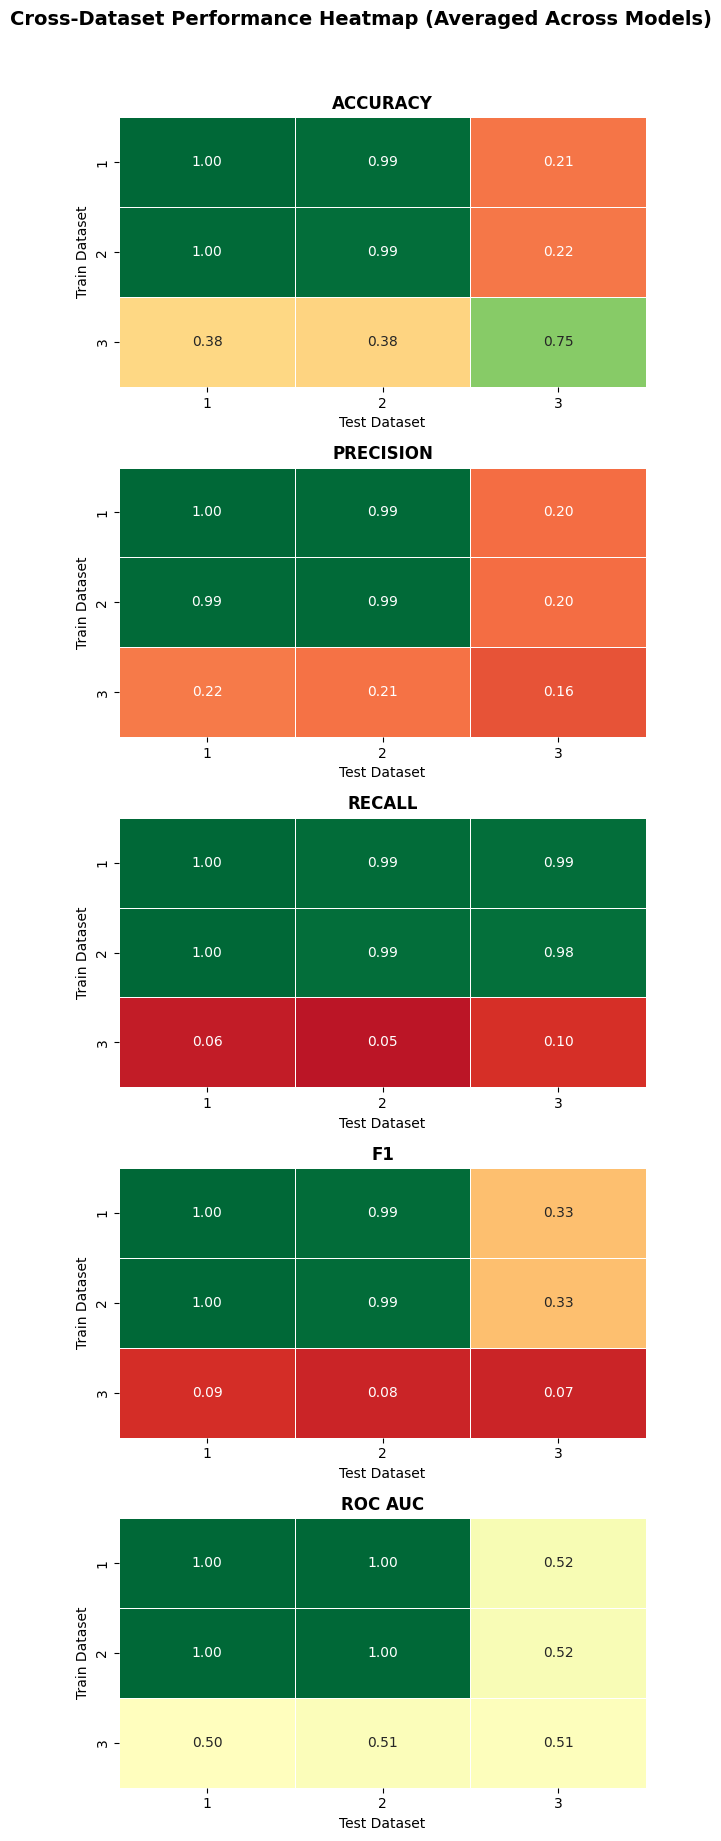

In [45]:
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
fig, axes = plt.subplots(len(metrics), 1, figsize=(6, 18)) 

for ax, metric in zip(axes, metrics):
    pivot = results_df.groupby(['train_dataset', 'test_dataset'])[metric].mean().unstack()
    
    sns.heatmap(
        pivot,
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn",
        vmin=0,
        vmax=1,
        linewidths=0.5,
        cbar=False
    )
    
    ax.set_title(metric.upper().replace('_', ' '), fontsize=12, fontweight='bold')
    ax.set_xlabel('Test Dataset')
    ax.set_ylabel('Train Dataset')

plt.suptitle('Cross-Dataset Performance Heatmap (Averaged Across Models)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Bar Chart Comparing Balancing VS No Balancing Across Models

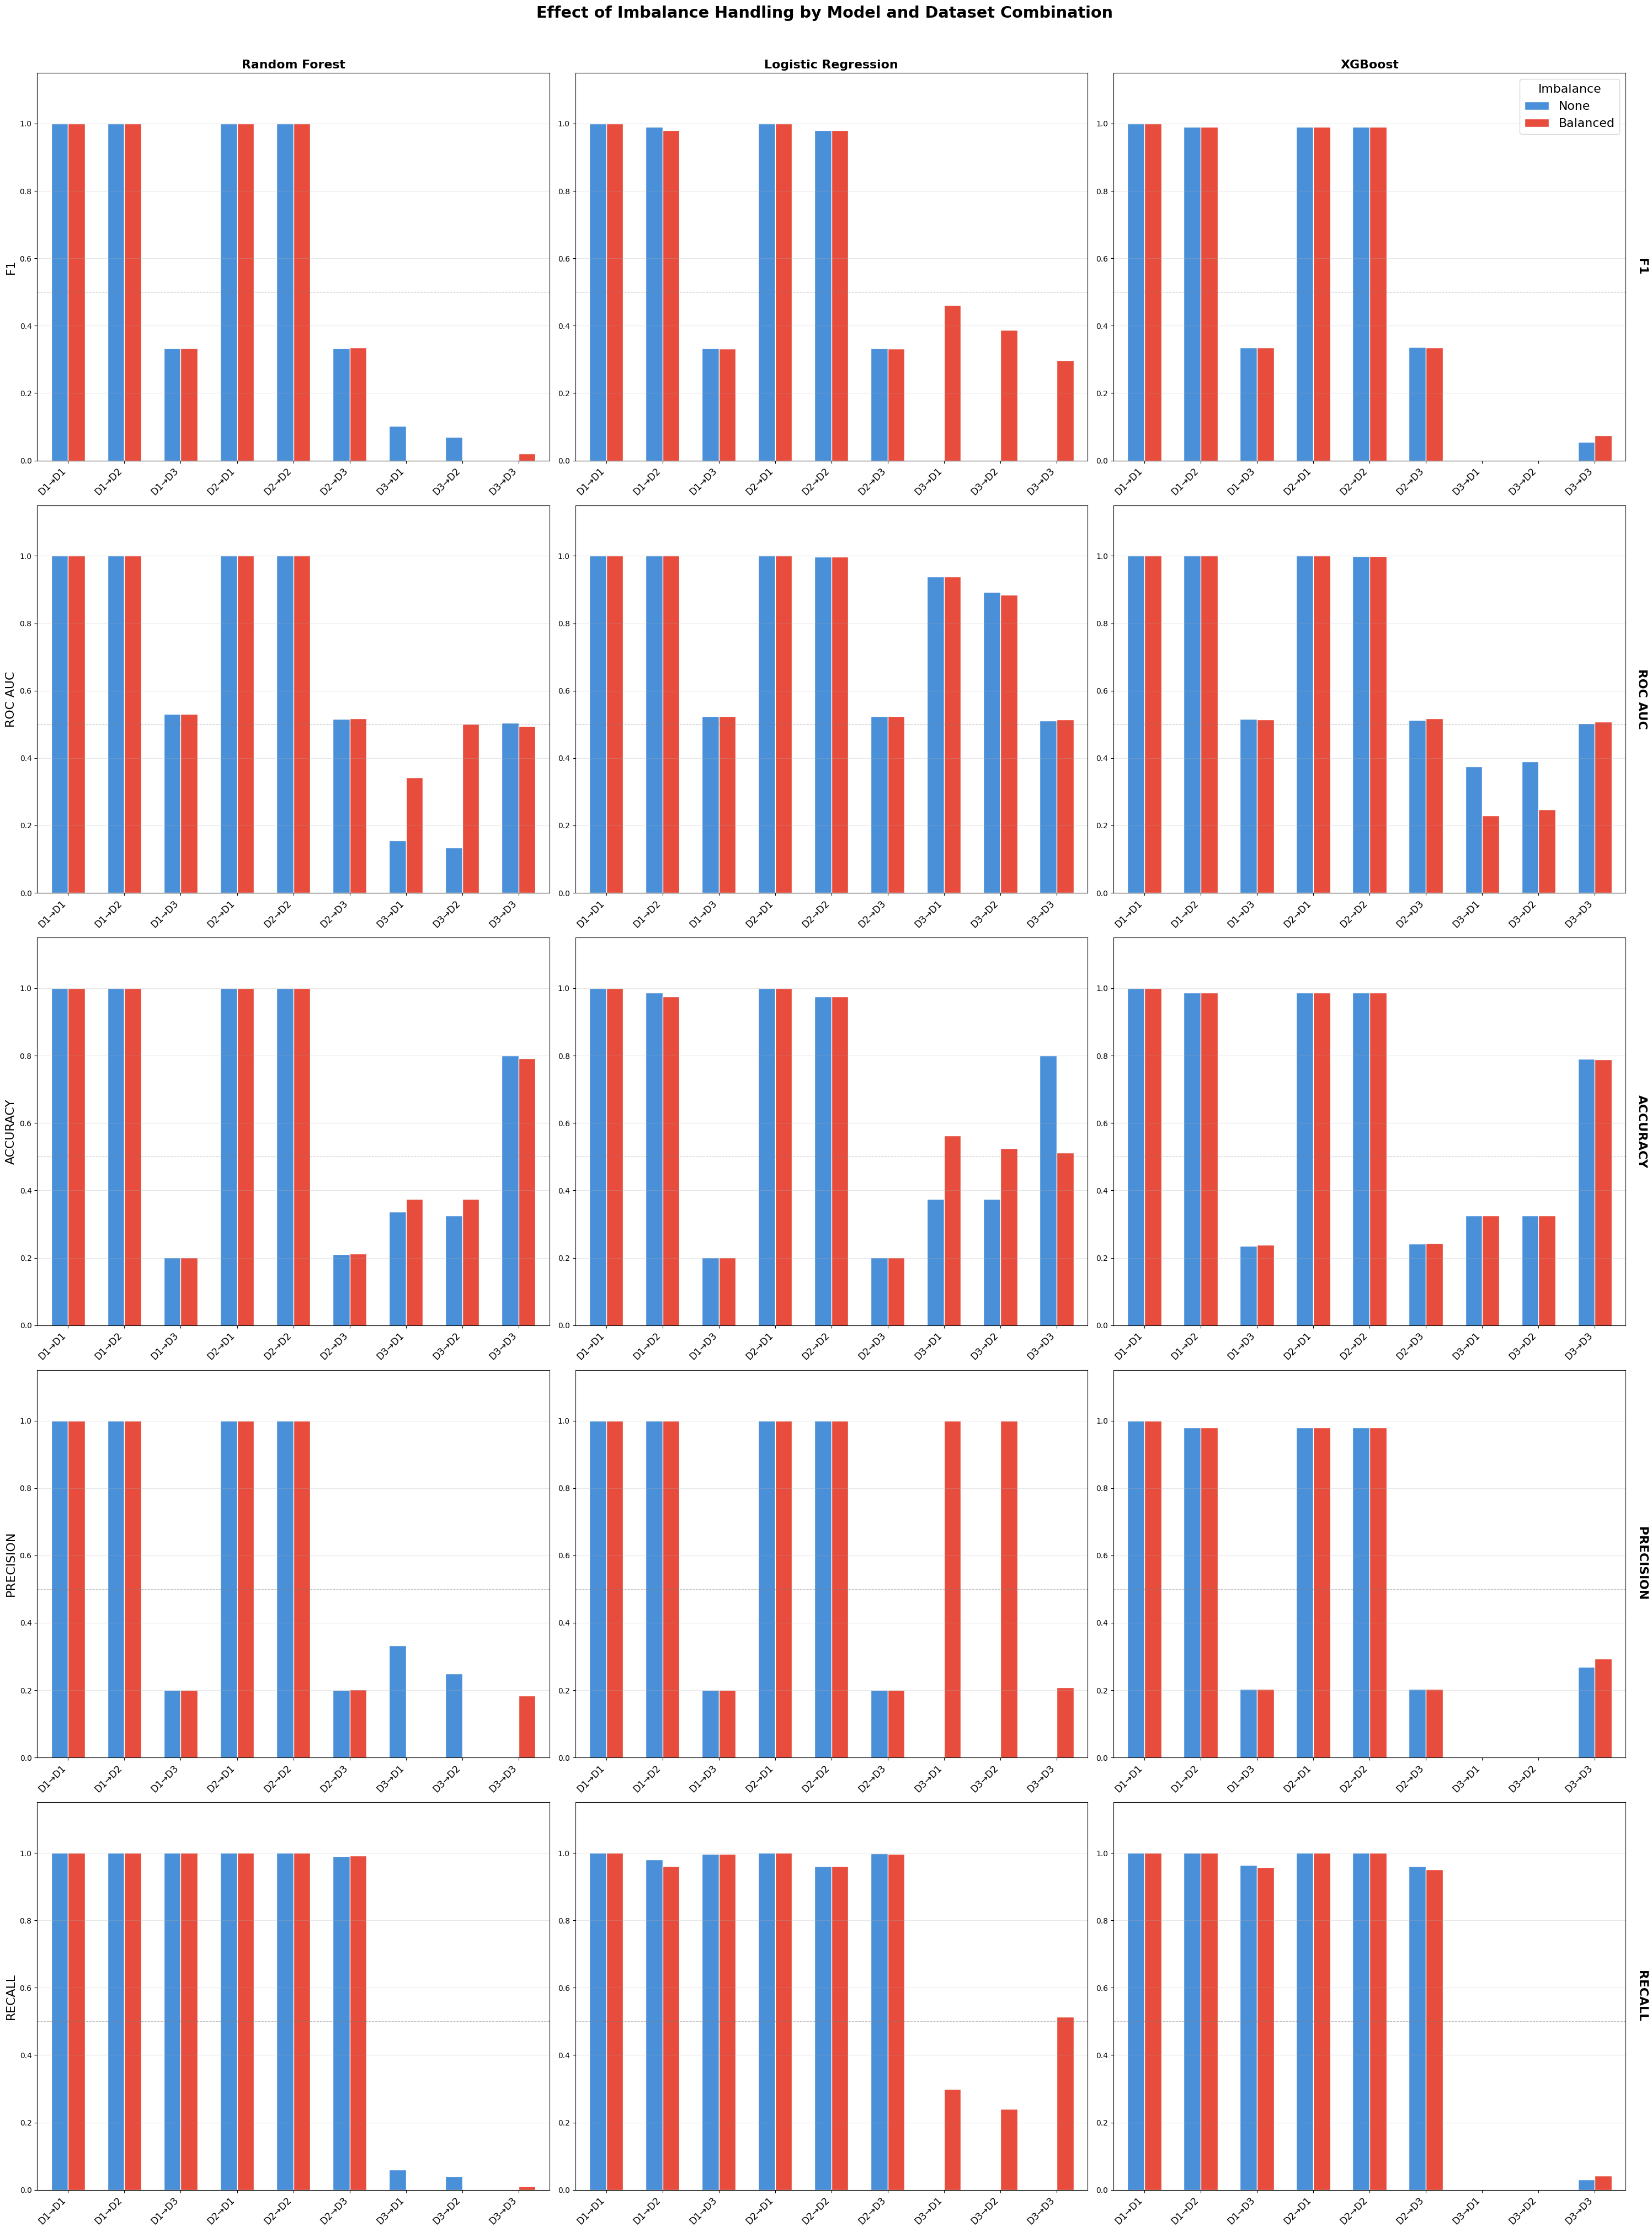

In [46]:
metrics = ['f1', 'roc_auc', 'accuracy', 'precision', 'recall']
models = results_df['model'].unique()

n_rows = len(metrics)
n_cols = len(models)

# Scale figure and fonts dynamically
col_w, row_h = 10, 8
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * col_w, n_rows * row_h))

# Scale fonts relative to subplot size
base_font = min(col_w, row_h) * 1.8
title_font = base_font * 1.1
tick_font  = base_font * 0.85
label_font = base_font * 1.1

for row, metric in enumerate(metrics):
    for col, model in enumerate(models):
        ax = axes[row, col]

        plot_data = []
        for imbalance in ['None', 'Balanced']:
            subset = results_df[
                (results_df['model'] == model) &
                (results_df['imbalance_handling'] == imbalance)
            ].copy()

            subset['experiment'] = 'D' + subset['train_dataset'].astype(str) + '→D' + subset['test_dataset'].astype(str)
            subset['label'] = imbalance
            plot_data.append(subset[['experiment', 'label', metric]])

        plot_df = pd.concat(plot_data)
        pivot = plot_df.pivot_table(index='experiment', columns='label', values=metric)
        pivot = pivot[['None', 'Balanced']]

        pivot.plot(
            kind='bar',
            ax=ax,
            width=0.6,
            color=['#4A90D9', '#E74C3C'],
            edgecolor='white'
        )

        # Only show model name on top row
        ax.set_title(model if row == 0 else '', fontsize=title_font, fontweight='bold')

        # Only show metric label on left column
        ax.set_ylabel(metric.upper().replace('_', ' ') if col == 0 else '', fontsize=label_font)
        ax.set_xlabel('')

        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=tick_font)
        ax.set_ylim(0, 1.15)
        ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.grid(axis='y', alpha=0.3)

        # Only show legend on top-right subplot
        if row == 0 and col == n_cols - 1:
            ax.legend(title='Imbalance', fontsize=label_font, title_fontsize=label_font)
        else:
            ax.get_legend().remove()

# Add row labels (metrics) on the right side
for row, metric in enumerate(metrics):
    axes[row, -1].annotate(
        metric.upper().replace('_', ' '),
        xy=(1.02, 0.5), xycoords='axes fraction',
        fontsize=label_font, fontweight='bold',
        va='center', ha='left', rotation=270
    )

plt.suptitle(
    'Effect of Imbalance Handling by Model and Dataset Combination',
    fontsize=title_font * 1.3, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

# Insights


- All models achieved perfect or near-perfect performance when trained and tested on the same dataset. For example, Random Forest, Logistic Regression, and XGBoost all achieved accuracy, precision, recall, F1-score, and ROC AUC values of 1.00 for Dataset 1 → Dataset 1 and Dataset 2 → Dataset 2. This indicates that the models are able to learn dataset-specific patterns extremely well.
- Models trained on Dataset 1 generalised well to Dataset 2 and vice versa. For instance, Random Forest achieved 1.00 accuracy for both (1 → 2) and (2 → 1), while Logistic Regression and XGBoost achieved high accuracy values of approximately 0.97–0.99 with F1-scores above 0.97. This suggests strong similarity between Dataset 1 and Dataset 2.
- When models trained on Dataset 1 or Dataset 2 were evaluated on Dataset 3, performance dropped significantly. Accuracy values were approximately 0.20–0.24 across all models, with precision around 0.20 and F1-scores around 0.33. Despite this, recall remained extremely high (~0.95–1.00), indicating that the models predicted most instances as the positive class, leading to poor overall classification performance.
- The combination of very high recall (~1.00) and very low precision (~0.20) when testing on Dataset 3 indicates that the models predict most instances as the positive class (CKD), resulting in a large number of false positives and poor overall classification performance. This indicates both class imbalance and a distribution mismatch between Dataset 3 and the other datasets.
- Models trained on Dataset 3 performed poorly when tested on Datasets 1 and 2. For example, Random Forest achieved accuracy values of approximately 0.33–0.37 with extremely low recall (as low as 0.04–0.06) and F1-scores below 0.10. This indicates that models trained on Dataset 3 fail to generalise to other datasets. D3 trained models are biased towards predicting 0, but D1/D2 test sets are majority class 1 (63%), so the model is predicting the wrong class most of the time. 
- Even when trained and tested on Dataset 3, models struggled to correctly classify the positive class. For example, Random Forest achieved an accuracy of 0.80 but with precision and recall equal to 0.00, indicating that the model predicted only the majority class. This demonstrates severe class imbalance in Dataset 3.
- Applying imbalance handling techniques resulted in modest improvements in certain cases for Dataset 3. For example, Logistic Regression (balanced) improved recall from 0.00 to 0.30 and achieved an F1-score of 0.46 training on Dataset 3 and testing on Dataset 1. However, these improvements were limited and did not significantly improve cross-dataset performance, suggesting that dataset differences have a greater impact than class imbalance alone.
- XGBoost generally showed slightly better performance on cross-dataset evaluations involving Dataset 3, achieving higher accuracy values (~0.24) compared to Random Forest (~0.21) and Logistic Regression (~0.20). Logistic Regression showed more stable performance under imbalance handling, particularly on Dataset 3. while tree-based models exhibited more extreme behaviours such as high accuracy but very low F1-scores. It is important to note that differences between models in cross-dataset scenarios were minimal, indicating that model choice had less impact than dataset characteristics such as distribution and feature consistency.
- ROC AUC scores for Dataset 1 and Dataset 2 were consistently near 1.00, indicating excellent class separability. However, for Dataset 3, ROC AUC values were close to 0.50 across all models, confirming that the models performed close to random guessing in cross-dataset scenarios.
- The detailed results show that while models perform extremely well within the same dataset, their performance deteriorates significantly when applied to different datasets, particularly Dataset 3. This indicates that dataset shift and differences in feature distributions have a greater impact on model performance than the choice of model or imbalance handling technique.